In [1]:
# Description: This program uses an artificial recurrent neural network called Long Short Term Memory (LSTM) to predict 
#the closing stock price of a corporation (Apple Inc.) using the past 60 day stock price.

In [2]:
#Import the libraries
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, GRU
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [3]:
#Get the stock quote 
dataset = web.DataReader('AAPL', data_source='yahoo', start='2012-01-01', end='2020-11-24') 
#Show the data 
data=dataset

In [4]:
y_data=dataset.filter(['Close']).values
y_test=y_data
y_data

array([[ 14.6867857 ],
       [ 14.76571369],
       [ 14.92964268],
       ...,
       [117.33999634],
       [113.84999847],
       [115.16999817]])

C:\Users\himal\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\converter.py:103: FutureWarning: Using an implicitly registered datetime converter for a matplotlib plotting method. The converter was registered by pandas on import. Future versions of pandas will require you to explicitly register matplotlib converters.

To register the converters:
	>>> from pandas.plotting import register_matplotlib_converters
	>>> register_matplotlib_converters()
  warnings.warn(msg, FutureWarning)


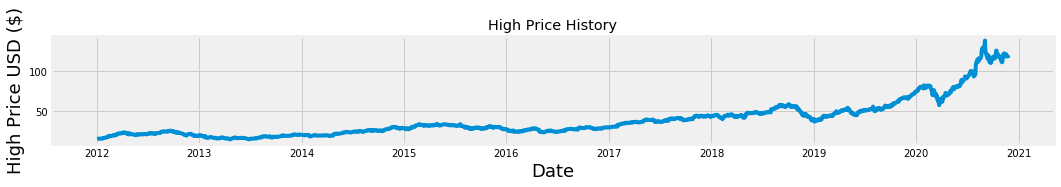

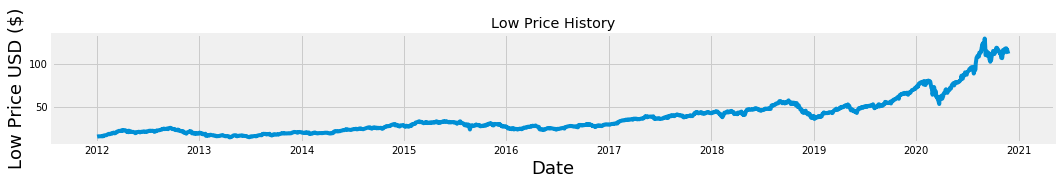

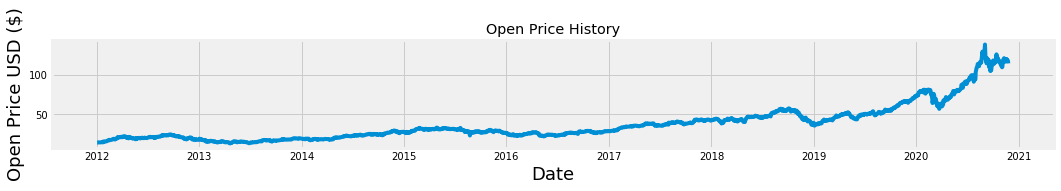

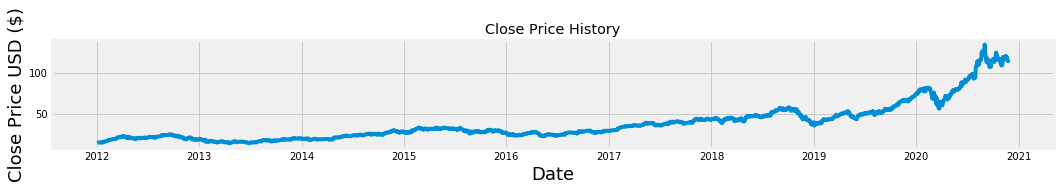

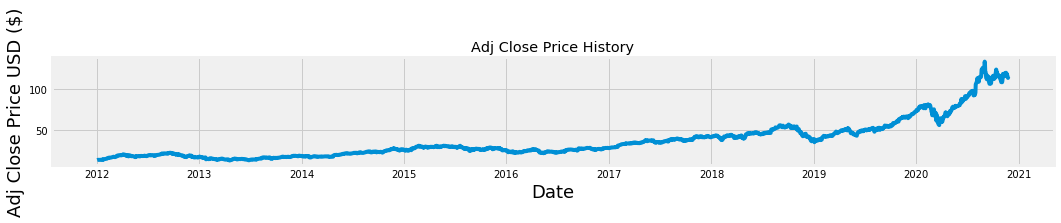

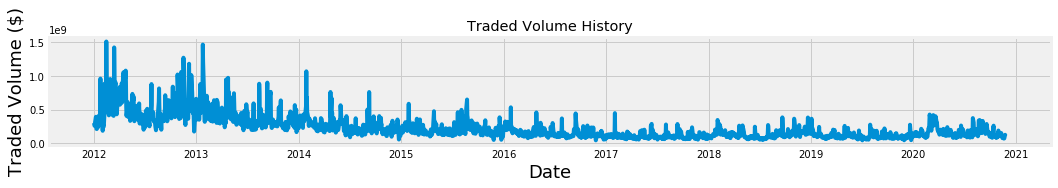

In [5]:
#Visualize the closing price history
plt.figure(figsize=(16,2))
plt.title('High Price History')
plt.plot(dataset['High'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('High Price USD ($)',fontsize=18)
plt.show()
plt.figure(figsize=(16,2))
plt.title('Low Price History')
plt.plot(dataset['Low'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Low Price USD ($)',fontsize=18)
plt.show()
plt.figure(figsize=(16,2))
plt.title('Open Price History')
plt.plot(dataset['Open'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Open Price USD ($)',fontsize=18)
plt.show()
plt.figure(figsize=(16,2))
plt.title('Close Price History')
plt.plot(dataset['Close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price USD ($)',fontsize=18)
plt.show()
plt.figure(figsize=(16,2))
plt.title('Adj Close Price History')
plt.plot(dataset['Adj Close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Adj Close Price USD ($)',fontsize=18)
plt.show()
plt.figure(figsize=(16,2))
plt.title('Traded Volume History')
plt.plot(dataset['Volume'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Traded Volume ($)',fontsize=18)
plt.show()

In [6]:
# Converting the dataframe to a numpy array
dataset = dataset.values

#Get /Compute the number of rows to train the model on
training_data_len = math.ceil( len(dataset) *.8) 
training_data_len

1792

In [7]:
#Scale the all of the data to be values between 0 and 1 
scaler = MinMaxScaler(feature_range=(0, 1)) 
scaled_data = scaler.fit_transform(dataset)
y_data=scaler.fit_transform(y_data)
len(y_data)

2240

In [8]:
#Create the scaled training data set 
train_data = scaled_data[0:training_data_len, : ]
print(len(train_data))
#Split the data into x_train and y_train data sets
x_train=train_data
y_train_data=[]
for i in range(60,len(train_data)):
     y_train_data.append(y_data[i,0])
y_train_data

1792


[0.06515055661523342,
 0.062088042929699744,
 0.06775563656793951,
 0.0709310214519843,
 0.06944283492600703,
 0.07222614508465441,
 0.07298359569819068,
 0.0706696330137738,
 0.07000425610876296,
 0.06898538532934267,
 0.06377524128776726,
 0.056319460106678265,
 0.06510302856031572,
 0.06469905595735218,
 0.058490838626342134,
 0.05419559377809535,
 0.05381536933875389,
 0.050423141670106336,
 0.065192135731368,
 0.06450894373768143,
 0.0631128309202296,
 0.05746306823450234,
 0.056913544929312554,
 0.05805715305713663,
 0.05682145535695035,
 0.0518994461823542,
 0.05315594137252613,
 0.05276978385823833,
 0.0530668183376371,
 0.05346485786565433,
 0.05233313175155968,
 0.04981122589495954,
 0.04831115735525285,
 0.04620512197918242,
 0.04146430954800073,
 0.041541534705323596,
 0.05072017614950511,
 0.04943993279571107,
 0.0534767557432205,
 0.05192024367233988,
 0.051020193030213795,
 0.053984684068438926,
 0.056034291777172174,
 0.05560655514674978,
 0.05063403551592599,
 0.051614

In [9]:
x_final=np.empty((1,6))
for i in range(60,len(train_data)):
    x_final=np.concatenate((x_final,x_train[i-60:i]),axis=0)
x_final = np.delete(x_final, (0), axis=0)
x_final.shape
print(x_final)

[[0.00372419 0.00730946 0.00618551 0.0061488  0.17579087 0.00377979]
 [0.00435355 0.00739509 0.00635869 0.00680526 0.14690088 0.0043391 ]
 [0.0054708  0.00843186 0.00778745 0.00816869 0.15460117 0.0055007 ]
 ...
 [0.23020694 0.24552411 0.23169822 0.23932798 0.02990815 0.24395762]
 [0.23319783 0.2459951  0.2343046  0.23785166 0.03047419 0.24252734]
 [0.23073236 0.24483906 0.23091024 0.23914085 0.02868187 0.24377631]]


In [10]:
x_train=x_final

In [11]:
#Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train_data)

In [12]:
#Reshape the data into the shape accepted by the LSTM
x_train = np.reshape(x_train, (1732,60,x_train.shape[1]))

In [13]:
x_train[0]

array([[0.00372419, 0.00730946, 0.00618551, 0.0061488 , 0.17579087,
        0.00377979],
       [0.00435355, 0.00739509, 0.00635869, 0.00680526, 0.14690088,
        0.0043391 ],
       [0.0054708 , 0.00843186, 0.00778745, 0.00816869, 0.15460117,
        0.0055007 ],
       [0.00668333, 0.01043509, 0.00917868, 0.00946678, 0.18679402,
        0.00660664],
       [0.00812682, 0.01108651, 0.01083258, 0.00926776, 0.23864112,
        0.00643709],
       [0.0076216 , 0.01113239, 0.01095091, 0.00971629, 0.14565104,
        0.00681922],
       [0.0067122 , 0.01046261, 0.01001861, 0.00951133, 0.11613613,
        0.00664458],
       [0.00672663, 0.01029134, 0.00990316, 0.00916676, 0.11442624,
        0.00635105],
       [0.00601933, 0.01026382, 0.00915848, 0.00869743, 0.12362365,
        0.00595117],
       [0.00761871, 0.01157891, 0.01045734, 0.01014998, 0.13517696,
        0.00718869],
       [0.00862337, 0.0126004 , 0.01125399, 0.01145994, 0.15838135,
        0.00830475],
       [0.00917189, 0

In [14]:
#Build the LSTM network model
model = Sequential()
model.add(GRU(units=50, return_sequences=True,input_shape=(x_train.shape[1],6)))
model.add(GRU(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

In [15]:
#Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [16]:
#Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

1732/1732 [==============================] - 60s 35ms/step - loss: 2.0401e-04


In [17]:
#Test data set
test_data = scaled_data[training_data_len - 60: , : ]
#Create the x_test and y_test data sets
x_test =  test_data #Get all of the rows from index 1603 to the rest and all of the columns (in this case it's only column 'Close'), so 2003 - 1603 = 400 rows of data
x_final_test=np.empty((1,6))
y_test =  y_test[training_data_len : , : ]
for i in range(60,len(test_data)):
    x_final_test=np.concatenate((x_final_test,test_data[i-60:i]),axis=0)
x_final_test = np.delete(x_final_test, (0), axis=0)
x_test=x_final_test
print(len(y_test))
print(len(x_test))

448
26880


In [18]:
#Convert x_test to a numpy array 
y_test = np.array(y_test)
y_test

array([[ 42.73249817],
       [ 43.00749969],
       [ 42.76499939],
       [ 43.24250031],
       [ 43.55749893],
       [ 43.58250046],
       [ 43.71749878],
       [ 43.28749847],
       [ 43.74250031],
       [ 43.96250153],
       [ 43.88249969],
       [ 43.63000107],
       [ 43.125     ],
       [ 43.22750092],
       [ 44.72499847],
       [ 45.22750092],
       [ 45.42750168],
       [ 45.93249893],
       [ 46.52999878],
       [ 47.00500107],
       [ 46.63249969],
       [ 47.04000092],
       [ 48.77249908],
       [ 47.76250076],
       [ 47.18500137],
       [ 46.69749832],
       [ 47.11750031],
       [ 47.18000031],
       [ 47.48749924],
       [ 47.81000137],
       [ 48.50500107],
       [ 48.83750153],
       [ 48.92250061],
       [ 49.25      ],
       [ 50.02500153],
       [ 49.875     ],
       [ 50.15499878],
       [ 49.73749924],
       [ 49.71749878],
       [ 49.80749893],
       [ 49.8125    ],
       [ 50.78250122],
       [ 50.96500015],
       [ 51

In [19]:
#Reshape the data into the shape accepted by the LSTM
x_test = np.reshape(x_test, (448,60,x_test.shape[1]))
print(x_test)
print(y_test[62])

[[[0.27001825 0.27825762 0.27190545 0.27045518 0.08369655 0.27251501]
  [0.25136554 0.2579624  0.24840744 0.25199094 0.15462253 0.25470312]
  [0.2489405  0.2601889  0.25115527 0.25157508 0.0541181  0.2543019 ]
  ...
  [0.23319783 0.2459951  0.2343046  0.23785166 0.03047419 0.24252734]
  [0.23073236 0.24483906 0.23091024 0.23914085 0.02868187 0.24377631]
  [0.23162155 0.24563116 0.23402174 0.2383507  0.0363252  0.24301083]]

 [[0.25136554 0.2579624  0.24840744 0.25199094 0.15462253 0.25470312]
  [0.2489405  0.2601889  0.25115527 0.25157508 0.0541181  0.2543019 ]
  [0.24152388 0.25066215 0.24147726 0.24223899 0.03357906 0.24529565]
  ...
  [0.23073236 0.24483906 0.23091024 0.23914085 0.02868187 0.24377631]
  [0.23162155 0.24563116 0.23402174 0.2383507  0.0363252  0.24301083]
  [0.23109613 0.24507455 0.23091024 0.23941114 0.02084191 0.24403818]]

 [[0.2489405  0.2601889  0.25115527 0.25157508 0.0541181  0.2543019 ]
  [0.24152388 0.25066215 0.24147726 0.24223899 0.03357906 0.24529565]
  [0

In [20]:
#Getting the models predicted price values
predictions = model.predict(x_test) 
predictions = scaler.inverse_transform(predictions)#Undo scaling
predictions.shape

(448, 1)

In [21]:
#Calculate/Get the value of RMSE
rmse=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse

4.362735497067968

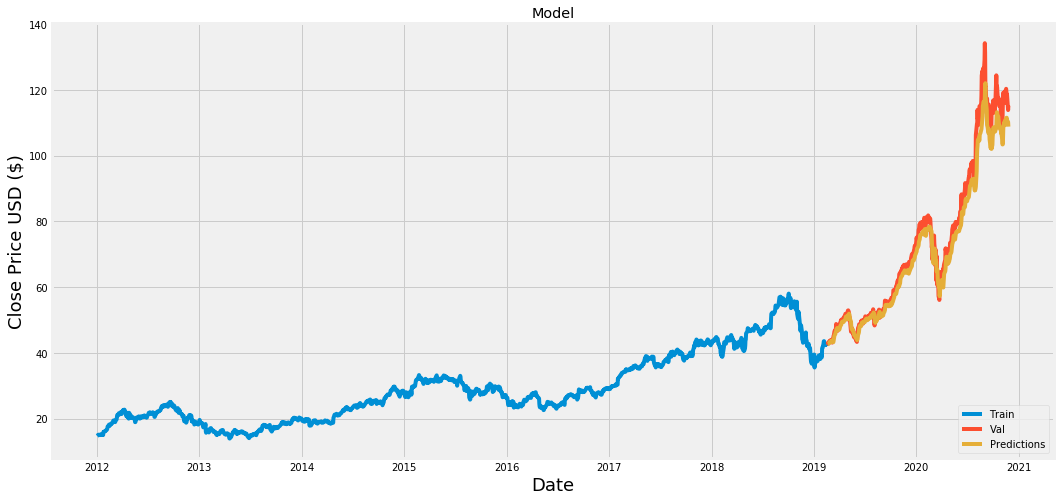

                 Close  predictions
Date                               
2019-02-19   42.732498    42.642769
2019-02-20   43.007500    42.657272
2019-02-21   42.764999    42.773060
2019-02-22   43.242500    42.832451
2019-02-25   43.557499    42.953365
...                ...          ...
2020-11-18  118.029999   111.500069
2020-11-19  118.639999   110.933289
2020-11-20  117.339996   110.596436
2020-11-23  113.849998   110.227600
2020-11-24  115.169998   108.804489

[448 rows x 2 columns]


In [22]:
# #Plot/Create the data for the graph
train = data[:training_data_len]
test = data[training_data_len:]
train=train['Close']
test=test['Close']
valid=pd.DataFrame(test)
valid['predictions']=predictions

#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train)
plt.plot(valid[['Close', 'predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()
print(valid)

In [23]:
#Show the valid and predicted prices
valid

,Close,predictions
Date,,
2019-02-19,42.732498,42.642769
2019-02-20,43.007500,42.657272
2019-02-21,42.764999,42.773060
2019-02-22,43.242500,42.832451
2019-02-25,43.557499,42.953365
...,...,...
2020-11-18,118.029999,111.500069
2020-11-19,118.639999,110.933289
2020-11-20,117.339996,110.596436


In [24]:
#Get the quote
apple_quote = web.DataReader('AAPL', data_source='yahoo', start='2012-01-01', end='2020-11-24')
#Create a new dataframe
new_df = apple_quote
x_final_test=np.empty((1,6))
x_final_test=np.concatenate((x_final_test,new_df[-60:]),axis=0)
x_final_test = np.delete(x_final_test, (0), axis=0)
test_data=x_final_test
#Scale the data to be values between 0 and 1
test_data_scaled = scaler.transform(test_data)
#Create an empty list
X_test = []
#Append teh past 60 days
X_test=test_data_scaled
#Reshape the data
X_test = np.reshape(X_test, (1,60,X_test.shape[1]))
#Get the predicted scaled price
pred_price = model.predict(X_test)
#undo the scaling 
pred_price = scaler.inverse_transform(pred_price)
print(X_test.shape)
pred_price

(1, 60, 6)


array([[39.620827]], dtype=float32)

In [25]:
#Get the quote
apple_quote2 = web.DataReader('AAPL', data_source='yahoo', start='2020-11-25', end='2020-11-25')
print(apple_quote2['Close'])

Date
2020-11-24    115.169998
2020-11-25    116.029999
Name: Close, dtype: float64


In [26]:
X_test.shape[0]

1

In [27]:
X_test.shape[1]

60